In [64]:
import json
from pathlib import Path
from collections import Counter

# Load the emotion results
results_file = "emotion_results.json"
with open(results_file, "r") as f:
    results = json.load(f)

print(f"Total results loaded: {len(results)}")
print(f"\nAll unique emotions in results:")
unique_emotions = set(results.values())
for emotion in sorted(unique_emotions):
    print(f"  - {emotion}")


Total results loaded: 535

All unique emotions in results:
  - anger
  - angry
  - anxiety
  - confusion
  - curiosity
  - fear
  - happiness
  - neutral
  - sadness
  - surprise


In [65]:
# Define valid emotion labels
valid_emotions = {"anger", "boredom", "anxiety", "happiness", "sadness", "disgust", "neutral"}

# Create a dictionary with only valid classifications
valid_results = {}
invalid_results = {}

for filename, emotion in results.items():
    emotion_lower = emotion.lower()
    if emotion_lower in valid_emotions:
        valid_results[filename] = emotion_lower
    else:
        invalid_results[filename] = emotion

print(f"Valid classifications: {len(valid_results)}")
print(f"Invalid classifications: {len(invalid_results)}")
print(f"\nInvalid emotions found:")
invalid_emotion_counts = Counter(invalid_results.values())
for emotion, count in sorted(invalid_emotion_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  - '{emotion}': {count} occurrences")

print(f"\nValid emotion distribution:")
valid_emotion_counts = Counter(valid_results.values())
for emotion in sorted(valid_emotions):
    count = valid_emotion_counts.get(emotion, 0)
    print(f"  - {emotion}: {count}")


Valid classifications: 497
Invalid classifications: 38

Invalid emotions found:
  - 'fear': 22 occurrences
  - 'curiosity': 9 occurrences
  - 'surprise': 5 occurrences
  - 'angry': 1 occurrences
  - 'confusion': 1 occurrences

Valid emotion distribution:
  - anger: 61
  - anxiety: 14
  - boredom: 0
  - disgust: 0
  - happiness: 112
  - neutral: 194
  - sadness: 116


In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Use the extended emotion mapping to get all 497 files evaluated
extended_mapping = {
    'W': 'anger',
    'L': 'boredom',
    'E': 'disgust',
    'A': 'anxiety',
    'F': 'happiness',
    'T': 'sadness',  # Lachen = laughing/happiness
    'N': 'neutral'     # Neutral variant
}

# Extract ground truth for ALL valid results
ground_truth_all = {}
for filename in valid_results.keys():
    emotion_code = filename[5]
    if emotion_code in extended_mapping:
        ground_truth_all[filename] = extended_mapping[emotion_code]

# Prepare predictions and true labels for all files
filenames_all = sorted(ground_truth_all.keys())
true_labels_all = [ground_truth_all[filename] for filename in filenames_all]
pred_labels_all = [valid_results[filename] for filename in filenames_all]

print(f"Files evaluated: {len(filenames_all)} / {len(valid_results)}")
print(f"All valid datapoints now evaluated: {len(filenames_all) == len(valid_results)}\n")

# Calculate overall accuracy
overall_accuracy_all = accuracy_score(true_labels_all, pred_labels_all)
print(f"Overall Accuracy (all 497 files): {overall_accuracy_all:.2%}\n")

# Generate classification report
print("Detailed Classification Report:")
print("=" * 70)
print(classification_report(true_labels_all, pred_labels_all, 
                          labels=sorted(valid_emotions),
                          zero_division=0))

# Confusion matrix
print("\nConfusion Matrix:")
cm_all = confusion_matrix(true_labels_all, pred_labels_all, labels=sorted(valid_emotions))
print("Predicted →")
print("True ↓     " + "  ".join(f"{e[:4]:>6}" for e in sorted(valid_emotions)))
for i, emotion in enumerate(sorted(valid_emotions)):
    print(f"{emotion:>9} {cm_all[i]}")


Files evaluated: 497 / 497
All valid datapoints now evaluated: True

Overall Accuracy (all 497 files): 44.67%

Detailed Classification Report:
              precision    recall  f1-score   support

       anger       0.97      0.48      0.64       123
     anxiety       0.64      0.18      0.29        49
     boredom       0.00      0.00      0.00        78
     disgust       0.00      0.00      0.00        40
   happiness       0.36      0.61      0.45        66
     neutral       0.36      0.89      0.51        79
     sadness       0.38      0.71      0.49        62

    accuracy                           0.45       497
   macro avg       0.39      0.41      0.34       497
weighted avg       0.45      0.45      0.39       497


Confusion Matrix:
Predicted →
True ↓       ange    anxi    bore    disg    happ    neut    sadn
    anger [59  3  0  0 46 12  3]
  anxiety [ 0  9  0  0  7  9 24]
  boredom [ 0  0  0  0  6 57 15]
  disgust [ 0  2  0  0  7  7 24]
happiness [ 2  0  0  0 40 21  3

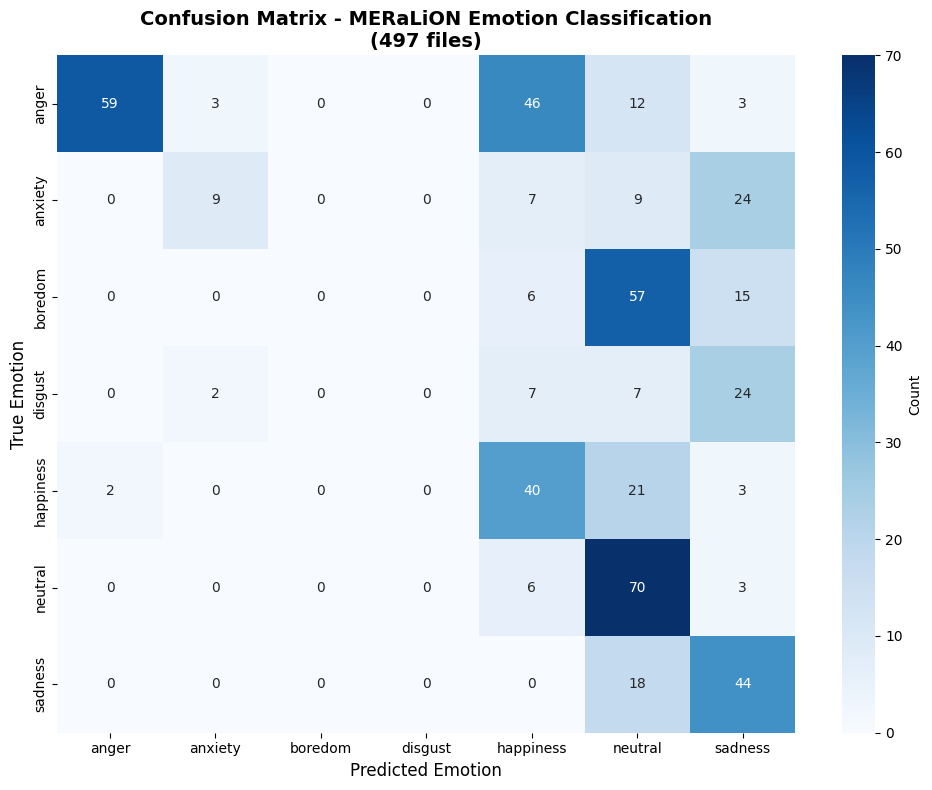

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_all, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=sorted(valid_emotions),
            yticklabels=sorted(valid_emotions),
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix - MERaLiON Emotion Classification\n(497 files)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('True Emotion', fontsize=12)
plt.tight_layout()
plt.show()
